In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, jarque_bera

In [57]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order, select_coint_rank

In [25]:
df = pd.read_csv(r'..\data\market_daily.csv')

In [26]:
df.head(5)

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price
0,2015-01-01,313.9,21370.0,NaN,2015-01-01,35.05
1,2015-01-02,315.1,21370.0,NaN,NaN,NaN
2,2015-01-03,282.0,NaN,NaN,NaN,NaN
3,2015-01-04,258.8,NaN,NaN,2015-01-04,35.16
4,2015-01-05,273.2,21370.0,544.45,NaN,NaN


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4065 entries, 0 to 4064
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ngày           4061 non-null   str    
 1   BTC_USD        4063 non-null   float64
 2   USD_VND        2905 non-null   float64
 3   VN_Index       2776 non-null   float64
 4   standard_time  2918 non-null   str    
 5   Gold_Price     2918 non-null   float64
dtypes: float64(4), str(2)
memory usage: 190.7 KB


In [28]:
df.describe()

,BTC_USD,USD_VND,VN_Index,Gold_Price
count,4063.000000,2905.000000,2776.000000,2918.000000
mean,28246.724317,23456.775215,1031.279856,49.912872
std,32252.978030,1204.385187,301.991684,15.812185
min,183.000000,21115.000000,521.880000,32.450000
25%,3820.250000,22715.000000,786.665000,36.425000
50%,11518.000000,23184.000000,1011.730000,41.837500
75%,43811.500000,23725.000000,1250.327500,66.487500
max,126110.000000,26457.000000,1902.930000,96.200000


Records by Month:
year_month
2015-01    25
2015-02    17
2015-03    26
2015-04    23
2015-05    26
           ..
2024-09    21
2024-10    26
2024-11    10
2024-12     8
2025-03     2
Freq: M, Length: 121, dtype: int64

Total months: 121


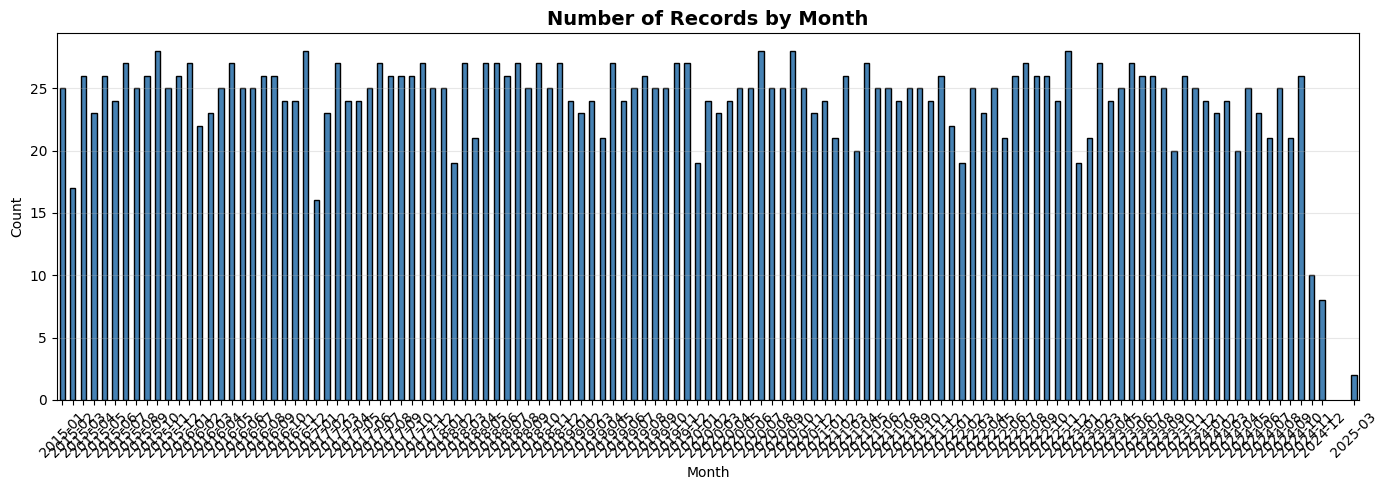

In [29]:
# check number of records by month
df['standard_time'] = pd.to_datetime(df['standard_time'])
df['year_month'] = df['standard_time'].dt.to_period('M')

# Records by month
monthly_count = df.groupby('year_month').size()
print("Records by Month:")
print(monthly_count)
print(f"\nTotal months: {len(monthly_count)}")

# Visualization
plt.figure(figsize=(14, 5))
monthly_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Records by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
df[df['Ngày'].isnull() & (df['standard_time'].isnull() ==False)]

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month


In [31]:
df.drop(columns='Ngày', inplace=True) 

In [32]:
df.head(5)

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
1,315.1,21370.0,NaN,NaT,NaN,NaT
2,282.0,NaN,NaN,NaT,NaN,NaT
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
4,273.2,21370.0,544.45,NaT,NaN,NaT


In [33]:
df.dropna(subset=['standard_time'], inplace=True)

In [34]:
df = df[df['standard_time'] <= pd.to_datetime('2024-10-31')]

In [35]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
...,...,...,...,...,...,...
3584,67081.0,NaN,NaN,2024-10-26,88.00,2024-10
3585,68035.0,NaN,NaN,2024-10-27,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [36]:
df.dropna(subset=['VN_Index'], inplace=True)

In [37]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
8,292.8,21340.0,569.73,2015-01-09,34.30,2015-01
11,267.6,21315.0,574.32,2015-01-12,33.01,2015-01
...,...,...,...,...,...,...
3582,68188.0,25385.0,1257.41,2024-10-24,88.00,2024-10
3583,66734.0,25355.0,1252.72,2024-10-25,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 2246 entries, 5 to 3589
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   BTC_USD        2246 non-null   float64       
 1   USD_VND        2246 non-null   float64       
 2   VN_Index       2246 non-null   float64       
 3   standard_time  2246 non-null   datetime64[us]
 4   Gold_Price     2246 non-null   float64       
 5   year_month     2246 non-null   period[M]     
dtypes: datetime64[us](1), float64(4), period[M](1)
memory usage: 122.8 KB


In [39]:
# convert to datetime and set index
df['standard_time'] = pd.to_datetime(df['standard_time'])
df.set_index('standard_time', inplace=True)

In [40]:
# convert unit of Gold price from million VND/tael to VND/tael
df['Gold_Price'] = df['Gold_Price'] * 1e6

In [41]:
def prepare_data(df):
    # Convert BTC/USD to BTC/VND
    df["BTC_VND"] = df["BTC_USD"] * df["USD_VND"]

    price = df[["VN_Index", "Gold_Price", "BTC_VND", "BTC_USD", "USD_VND"]].dropna()

    log_price = np.log(price)
    log_price.columns = [
        "ln_vnindex",
        "ln_gold",
        "ln_btc_vnd",
        "ln_btc_usd",
        "ln_usdvnd"
    ]

    ret = log_price.diff().dropna()
    ret.columns = [
        "r_vnindex",
        "r_gold",
        "r_btc_vnd",
        "r_btc_usd",
        "r_usdvnd"
    ]

    return price, log_price, ret

price, log_price, ret = prepare_data(df)

In [42]:
for data in [price, log_price, ret]:
    print(data.head())

               VN_Index  Gold_Price    BTC_VND  BTC_USD  USD_VND
standard_time                                                   
2015-01-06       549.66  34900000.0  6113268.0    285.4  21420.0
2015-01-07       552.05  34380000.0  6361740.0    297.0  21420.0
2015-01-08       553.47  33050000.0  6100416.0    285.6  21360.0
2015-01-09       569.73  34300000.0  6248352.0    292.8  21340.0
2015-01-12       574.32  33010000.0  5703894.0    267.6  21315.0
               ln_vnindex    ln_gold  ln_btc_vnd  ln_btc_usd  ln_usdvnd
standard_time                                                          
2015-01-06       6.309300  17.367997   15.625972    5.653892   9.972080
2015-01-07       6.313639  17.352986   15.665812    5.693732   9.972080
2015-01-08       6.316208  17.313532   15.623868    5.654592   9.969275
2015-01-09       6.345163  17.350656   15.647828    5.679490   9.968339
2015-01-12       6.353187  17.312321   15.556660    5.589493   9.967166
               r_vnindex    r_gold  r_btc

In [43]:
def make_weekly_data(price):
    weekly_price = price.resample("W-FRI").last().dropna()
    weekly_log = np.log(weekly_price)
    weekly_ret = weekly_log.diff().dropna()

    weekly_log.columns = [
        "ln_vnindex",
        "ln_gold",
        "ln_btc_vnd",
        "ln_btc_usd",
        "ln_usdvnd"
    ]

    weekly_ret.columns = [
        "r_vnindex",
        "r_gold",
        "r_btc_vnd",
        "r_btc_usd",
        "r_usdvnd"
    ]

    return weekly_price, weekly_log, weekly_ret

weekly_price, weekly_log, weekly_ret = make_weekly_data(price)

In [44]:
for data in [weekly_price, weekly_log, weekly_ret]:
    print(data.head())

               VN_Index  Gold_Price    BTC_VND  BTC_USD  USD_VND
standard_time                                                   
2015-01-09       569.73  34300000.0  6248352.0    292.8  21340.0
2015-01-16       574.81  35410000.0  4405810.5    206.7  21315.0
2015-01-23       582.38  35640000.0  5010200.0    235.0  21320.0
2015-01-30       576.07  35290000.0  4872269.7    229.1  21267.0
2015-02-06       574.13  34880000.0  4738982.4    223.2  21232.0
               ln_vnindex    ln_gold  ln_btc_vnd  ln_btc_usd  ln_usdvnd
standard_time                                                          
2015-01-09       6.345163  17.350656   15.647828    5.679490   9.968339
2015-01-16       6.354040  17.382505   15.298435    5.331268   9.967166
2015-01-23       6.367123  17.388979   15.426986    5.459586   9.967401
2015-01-30       6.356229  17.379110   15.399070    5.434159   9.964912
2015-02-06       6.352856  17.367424   15.371333    5.408068   9.963265
               r_vnindex    r_gold  r_btc

### Descriptive statistics:

In [45]:


def descriptive_stats(data):
    result = pd.DataFrame(index=data.columns)

    result["mean"] = data.mean()
    result["sd"] = data.std()
    result["skewness"] = data.apply(lambda x: skew(x.dropna()))
    result["kurtosis"] = data.apply(lambda x: kurtosis(x.dropna(), fisher=False))

    jb_stats = []
    jb_pvalues = []

    for col in data.columns:
        jb = jarque_bera(data[col].dropna())
        jb_stats.append(jb.statistic)
        jb_pvalues.append(jb.pvalue)

    result["JB_stat"] = jb_stats
    result["JB_pvalue"] = jb_pvalues

    return result

desc_return = descriptive_stats(ret[["r_vnindex", "r_gold", "r_btc_vnd"]])
print(desc_return)

               mean        sd  skewness   kurtosis       JB_stat  JB_pvalue
r_vnindex  0.000371  0.012084 -0.979018   8.297453   2983.689910        0.0
r_gold     0.000417  0.031306 -0.830165  20.373266  28491.582157        0.0
r_btc_vnd  0.002526  0.047375 -0.718338  12.785279   9149.845877        0.0


- Số liệu này minh chứng rõ nét cho nguyên tắc "High risk, high return". Bitcoin mang lại lợi nhuận cao nhất nhưng rủi ro đi kèm cũng lớn nhất. Điều này một lần nữa làm yếu đi luận điểm coi Bitcoin là một tài sản "trú ẩn an toàn" (safe haven) ổn định như Vàng.
- Việc skewness âm cho thấy chuỗi lợi nhuận của các tài sản này có xu hướng mang lại những khoản lãi nhỏ thường xuyên, nhưng thỉnh thoảng sẽ có những cú sụt giảm giá trị cực mạnh (downside risk). Trong đó, VN-Index có mức độ lệch âm cao nhất.
- Các sự kiện cực đoan (những ngày giá tăng phi mã hoặc sập hầm) xảy ra dày đặc hơn nhiều so với dự báo của phân phối chuẩn. Đặc biệt, Vàng có Kurtosis lên tới >20, nghĩa là bình thường giá Vàng biến động rất nhỏ (tập trung ở đỉnh nhọn), nhưng một khi có cú sốc vĩ mô xảy ra, nó sẽ phản ứng với biên độ cực kỳ dữ dội ở vùng "đuôi".
-Với p-value bằng 0, chúng ta bác bỏ hoàn toàn giả thuyết $H_0$ ở mức ý nghĩa 1%. Chuỗi lợi nhuận của VN-Index, Vàng và Bitcoin chắc chắn không tuân theo phân phối chuẩn.

In [46]:
corr_matrix = ret[["r_vnindex", "r_gold", "r_btc_vnd"]].corr()
print(corr_matrix)

           r_vnindex    r_gold  r_btc_vnd
r_vnindex   1.000000 -0.013212   0.071331
r_gold     -0.013212  1.000000  -0.029976
r_btc_vnd   0.071331 -0.029976   1.000000


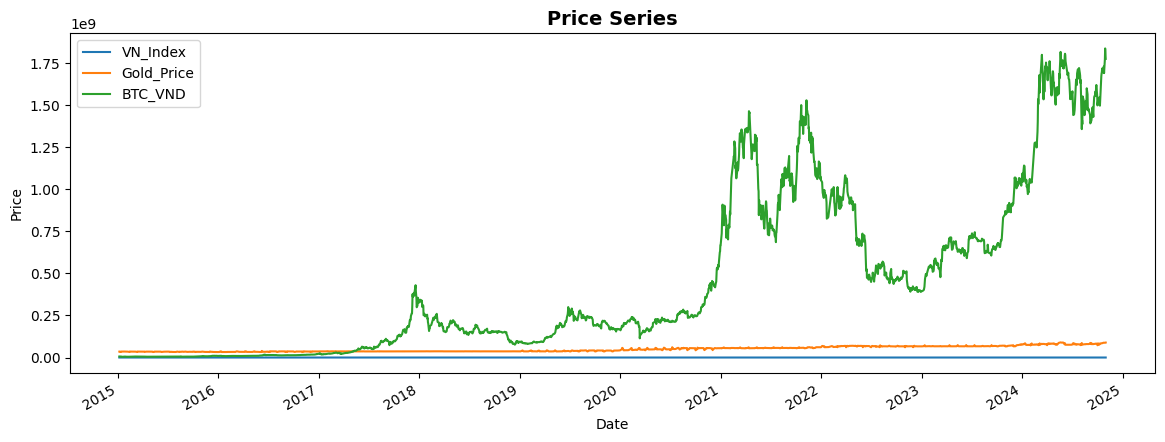

In [54]:
price[["VN_Index", "Gold_Price", "BTC_VND"]].plot(figsize=(14, 5))
plt.title("Price Series", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

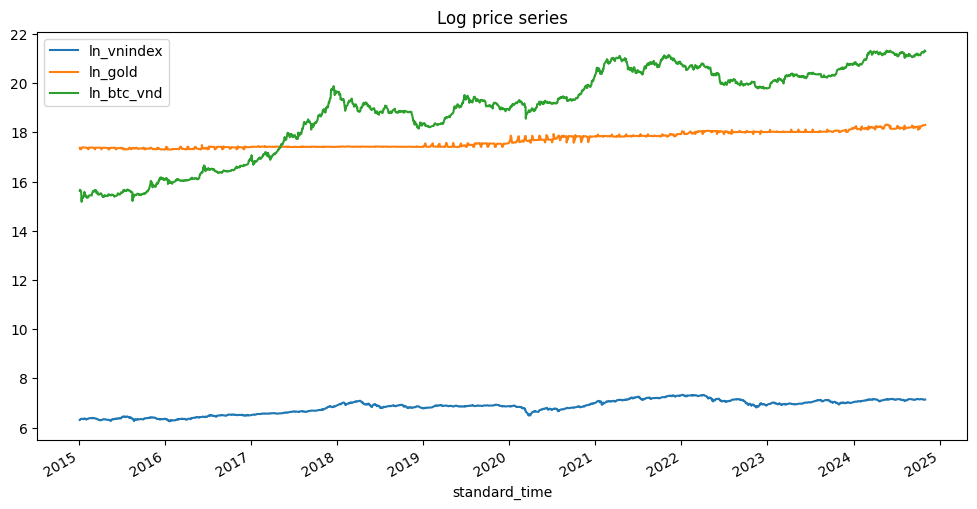

In [47]:
log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].plot(figsize=(12, 6))
plt.title("Log price series")
plt.show()

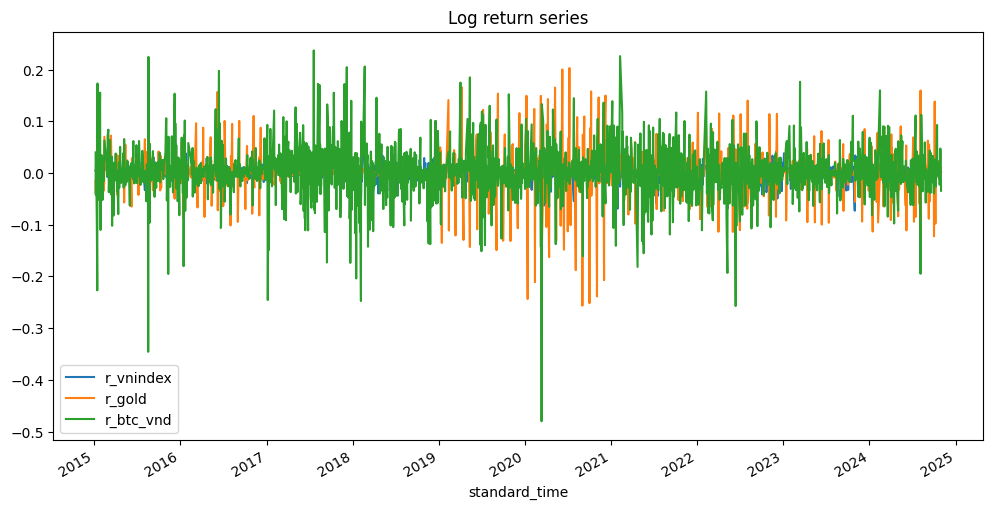

In [48]:
ret[["r_vnindex", "r_gold", "r_btc_vnd"]].plot(figsize=(12, 6))
plt.title("Log return series")
plt.show()

### Unit root test

In [56]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

def unit_root_tests(data, regression="c"):
    rows = []

    for col in data.columns:
        x = data[col].dropna()

        # ADF
        adf_res = adfuller(x, autolag="AIC")

        # PP
        pp_res = PhillipsPerron(x)

        # KPSS
        try:
            kpss_res = kpss(x, regression=regression, nlags="auto")
            kpss_stat = kpss_res[0]
            kpss_p = kpss_res[1]
        except Exception:
            kpss_stat = np.nan
            kpss_p = np.nan

        rows.append({
            "variable": col,
            "ADF_stat": adf_res[0],
            "ADF_pvalue": adf_res[1],
            "PP_stat": pp_res.stat,
            "PP_pvalue": pp_res.pvalue,
            "KPSS_stat": kpss_stat,
            "KPSS_pvalue": kpss_p
        })

    return pd.DataFrame(rows)

# Test log price level
unit_log = unit_root_tests(log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]])
print(unit_log)

# Test returns
unit_ret = unit_root_tests(ret[["r_vnindex", "r_gold", "r_btc_vnd"]])
print(unit_ret)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of th

     variable  ADF_stat  ADF_pvalue   PP_stat  PP_pvalue  KPSS_stat  \
0  ln_vnindex -1.540742    0.513269 -1.641885   0.461276   5.820096   
1     ln_gold  1.310463    0.996667 -0.320242   0.922588   7.254191   
2  ln_btc_vnd -1.207662    0.670291 -1.239786   0.656251   6.595908   

   KPSS_pvalue  
0         0.01  
1         0.01  
2         0.01  
    variable   ADF_stat    ADF_pvalue    PP_stat  PP_pvalue  KPSS_stat  \
0  r_vnindex -13.400288  4.580596e-25 -45.139916        0.0   0.083690   
1     r_gold -16.076381  5.437506e-29 -85.893987        0.0   0.321577   
2  r_btc_vnd -49.863424  0.000000e+00 -49.840181        0.0   0.133534   

   KPSS_pvalue  
0          0.1  
1          0.1  
2          0.1  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26460\2945059674.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression=regression, nlags="auto")


- Log price xuất hiện unit root
- return không xuất hiện unit root

### Johansen Cointegration test

In [60]:
levels = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].dropna()

# Chọn lag cho VECM
lag_order = select_order(levels, maxlags=10, deterministic="ci")
print(lag_order.summary())
p_lag = lag_order.aic
k_ar_diff = p_lag - 1
print("Selected k_ar_diff:", k_ar_diff)

# Johansen rank test
rank_test = select_coint_rank(
    levels,
    det_order=0,
    k_ar_diff=k_ar_diff,
    method="trace",
    signif=0.05
)

print(rank_test.summary())
print("Cointegration rank:", rank_test.rank)

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.90     -21.86*   3.095e-10      -21.88
1       -21.91      -21.85   3.047e-10      -21.89
2       -21.91      -21.83   3.046e-10      -21.88
3       -21.93      -21.82   2.999e-10      -21.89
4       -21.96      -21.83   2.907e-10      -21.91
5       -21.97      -21.82   2.866e-10     -21.92*
6       -21.98      -21.80   2.858e-10      -21.91
7       -21.98      -21.78   2.843e-10      -21.91
8       -21.98      -21.76   2.835e-10      -21.90
9      -21.99*      -21.74  2.831e-10*      -21.90
10      -21.98      -21.71   2.838e-10      -21.88
--------------------------------------------------
Selected k_ar_diff: 8
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   3          33.54          29.80
  1   3          

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

Cointegration rank: 1 đã xác nhận hệ thống 3 biến (VN-Index, Vàng, Bitcoin) có chính xác 1 mối quan hệ đồng tích hợp (1 phương trình cân bằng dài hạn).